In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from datetime import datetime
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

RANDOM_STATE=42

In [150]:
data = pd.read_csv('marketing_campaign.csv', sep='\t')
# Note: Was separated by tab
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [151]:
#TODO
# Change year birth to age from 2020, dt customer to 2020 too
# Encode ordinal: education, marital_status
# Or make marital status binary
# Consider adding all AcceptedCmp and Response together 
# Drop Z_CostContact, Z_Revenue
# make income ln


# Then make columns MntWines, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds target

In [152]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Prevent line wrapping
data.drop(columns=["ID"], inplace=True)
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [153]:
# data = data.drop(index=data[data['Income'] > 500000].index)


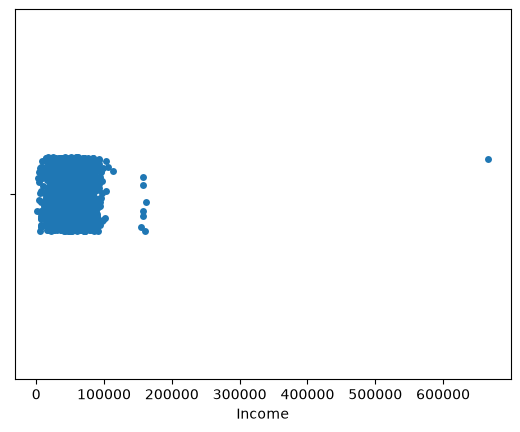

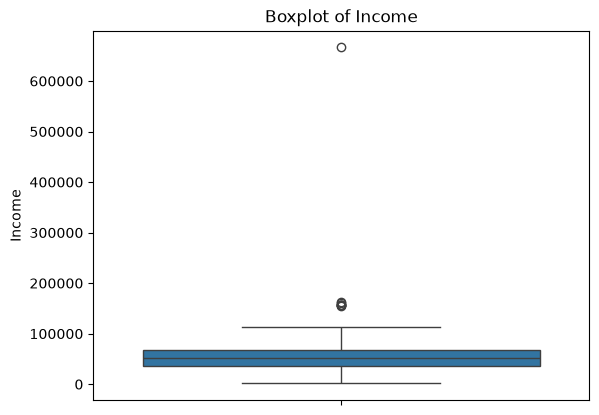

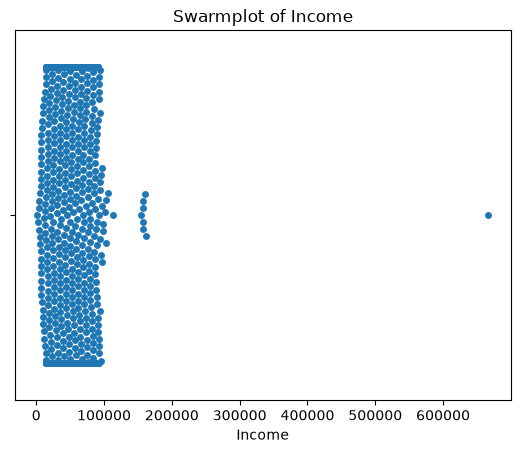

In [154]:
plt.figure()
# sns.boxplot(y=data["Income"])
# plt.title(f"Boxplot of Income")
# plt.show()

sns.stripplot(x=data["Income"], jitter=True)
plt.show()

plt.figure()
sns.boxplot(y=data["Income"])
plt.title(f"Boxplot of Income")
# plt.show()

# sns.stripplot(x=data["Income"], jitter=True)
plt.show()


plt.figure()
sns.swarmplot(x=data["Income"])
plt.title(f"Swarmplot of Income")
# plt.show()

# sns.stripplot(x=data["Income"], jitter=True)
plt.show()



In [155]:
# data = data.drop(index=data[data['Income'] > 500000].index)


In [156]:
data[data['Income'] < 10000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
9,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0
11,1976,Basic,Married,7500.0,0,0,13-11-2012,59,6,16,11,11,1,16,1,2,0,3,8,0,0,0,0,0,0,3,11,0
21,1979,Graduation,Married,2447.0,1,0,06-01-2013,42,1,1,1725,1,1,1,15,0,28,0,1,0,0,0,0,0,0,3,11,0
44,1975,Master,Married,7500.0,1,0,02-10-2013,19,3,1,10,3,2,12,3,2,0,3,5,0,0,0,0,0,0,3,11,0
46,1996,2n Cycle,Married,7500.0,0,0,09-11-2012,24,3,18,14,15,22,50,3,3,1,3,9,0,0,0,0,0,0,3,11,1
136,1976,Basic,Divorced,9548.0,1,0,08-08-2012,31,0,1,3,10,6,9,2,1,0,3,8,0,0,0,0,0,0,3,11,0
238,1973,Graduation,Single,7500.0,1,0,26-12-2013,54,5,3,10,12,7,20,4,3,1,3,7,0,0,0,0,0,0,3,11,0
439,1986,2n Cycle,Married,7500.0,1,0,07-02-2013,96,1,11,5,4,6,9,2,2,0,3,8,0,0,0,0,0,0,3,11,0
724,1976,Graduation,Married,7500.0,1,0,01-08-2012,19,7,0,12,13,7,32,5,4,1,2,9,1,0,0,0,0,0,3,11,1
774,1957,PhD,Together,6835.0,0,1,08-12-2012,76,107,2,12,2,2,12,0,0,0,1,20,0,0,0,0,0,0,3,11,0


In [157]:
data[data["Income"].isnull()]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
27,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0
43,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0
48,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0
58,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0
71,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0
90,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0
91,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
92,1973,Master,Together,NaN,0,0,23-11-2013,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0
128,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0


In [158]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2235    False
2236     True
2237    False
2238    False
2239    False
Length: 2240, dtype: bool

In [159]:
data.drop_duplicates().reset_index(drop=True)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0
2054,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2055,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2056,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [160]:
print(data["Education"].value_counts())
print(data["Marital_Status"].value_counts()) 



Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [161]:
data["Income"] = np.log1p(data["Income"])
data["Age"] = 2017 - data["Year_Birth"]
data["Days_enrolled"] = (pd.to_datetime("01-01-2017", format="%d-%m-%Y")-pd.to_datetime(data['Dt_Customer'], format="%d-%m-%Y")).dt.days

edu_order = {"Basic":0, "Graduation": 1, "2n Cycle": 2, "Master": 2, "PhD": 3}
data["Education"] = data["Education"].map(edu_order)

marital_order = {"Absurd":0, "YOLO": 0, "Alone": 1, "Single": 1, "Divorced": 2, "Widow": 2, "Together": 3, "Married": 4}
data["Marital_Status"] = data["Marital_Status"].map(marital_order)

data["Promotions"] = data["AcceptedCmp1"]+data["AcceptedCmp2"]+data["AcceptedCmp3"]+data["AcceptedCmp4"]+data["AcceptedCmp5"]+data["Response"]

data["Spent"] = data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]

data = data.drop(columns=["Z_CostContact", "Z_Revenue", "Year_Birth", "Dt_Customer", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"])

In [162]:
#TODO
# Change year birth to age from 2020, dt customer to 2020 too
# Encode ordinal: education, marital_status
# Or make marital status binary
# Consider adding all AcceptedCmp and Response together 
# Drop Z_CostContact, Z_Revenue, Year_Birth, Dt_Customer
# make income ln


In [163]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   int64  
 1   Marital_Status       2240 non-null   int64  
 2   Income               2216 non-null   float64
 3   Kidhome              2240 non-null   int64  
 4   Teenhome             2240 non-null   int64  
 5   Recency              2240 non-null   int64  
 6   MntWines             2240 non-null   int64  
 7   MntFruits            2240 non-null   int64  
 8   MntMeatProducts      2240 non-null   int64  
 9   MntFishProducts      2240 non-null   int64  
 10  MntSweetProducts     2240 non-null   int64  
 11  MntGoldProds         2240 non-null   int64  
 12  NumDealsPurchases    2240 non-null   int64  
 13  NumWebPurchases      2240 non-null   int64  
 14  NumCatalogPurchases  2240 non-null   int64  
 15  NumStorePurchases    2240 non-null   i

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Days_enrolled,Promotions,Spent
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1.665625,2.811161,10.753825,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,48.194196,1270.582143,0.446875,605.798214
std,0.839658,1.169266,0.505844,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,11.984069,202.122512,0.890543,602.249288
min,0.000000,0.000000,7.456455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,917.000000,0.000000,5.000000
25%,1.000000,2.000000,10.471751,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,40.000000,1097.750000,0.000000,68.750000
50%,1.000000,3.000000,10.847053,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,47.000000,1272.500000,0.000000,396.000000
75%,2.000000,4.000000,11.134924,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,58.000000,1446.000000,1.000000,1045.500000
max,3.000000,4.000000,13.410046,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,124.000000,1616.000000,5.000000,2525.000000


In [164]:
X = data
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median", add_indicator=True)),
    ('scaler', StandardScaler())
])
X_scaled = numeric_pipeline.fit_transform(X)

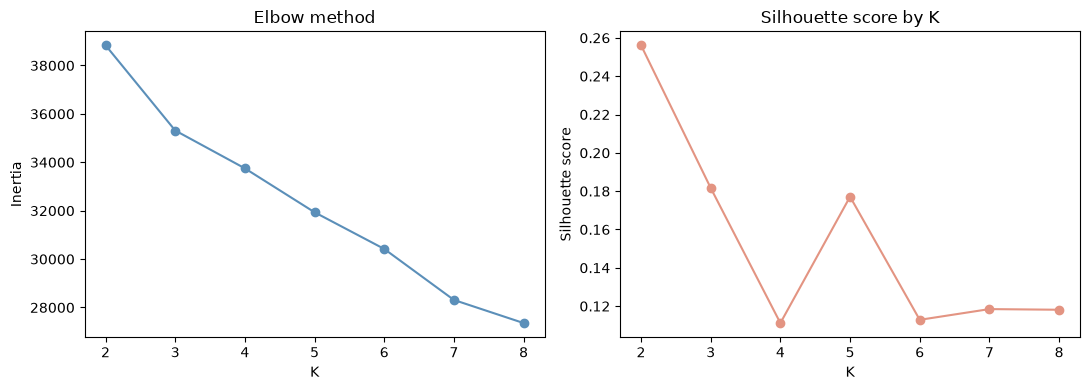

K with the highest silhouette score: 2


In [165]:
K_range = range(2, 9)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, "o-", color="#5B8FB9")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")

axes[1].plot(list(K_range), sil_scores, "o-", color="#E39482")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette score by K")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("K with the highest silhouette score:", best_k)


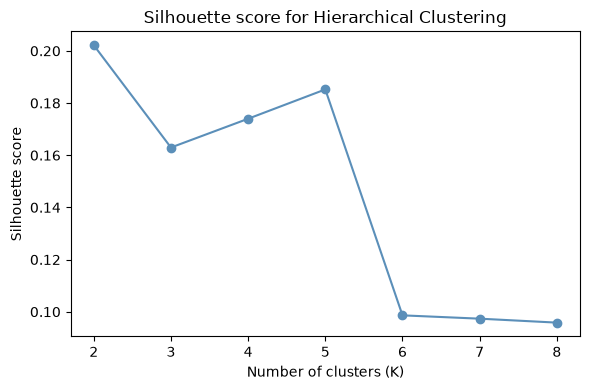

K with the highest silhouette score: 2


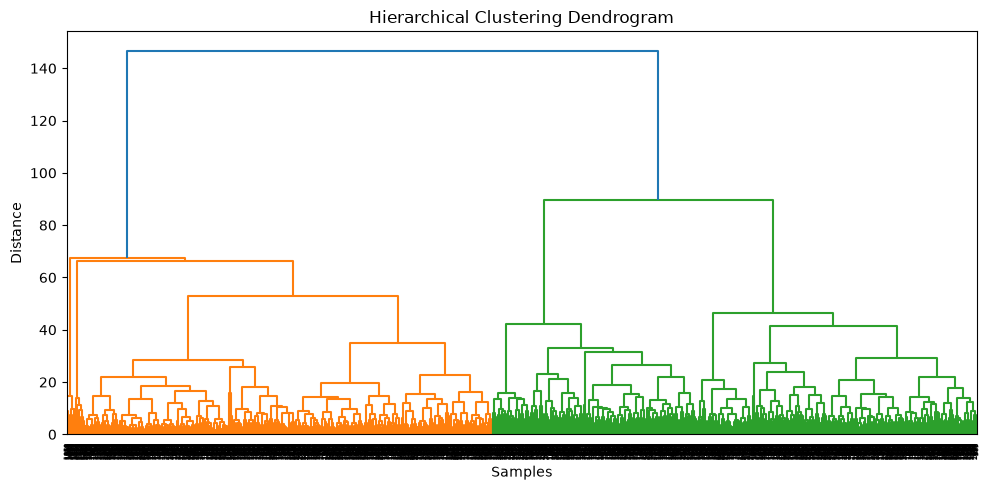

In [166]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

K_range = range(2, 9)
sil_scores = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), sil_scores, "o-", color="#5B8FB9")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for Hierarchical Clustering")
plt.tight_layout()
plt.show()

best_k_hc = list(K_range)[int(np.argmax(sil_scores))]
print("K with the highest silhouette score:", best_k_hc)

# Fit final hierarchical clustering model
hc_final = AgglomerativeClustering(
    n_clusters=best_k_hc,
    linkage="ward"
)

hc_labels = hc_final.fit_predict(X_scaled)

from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

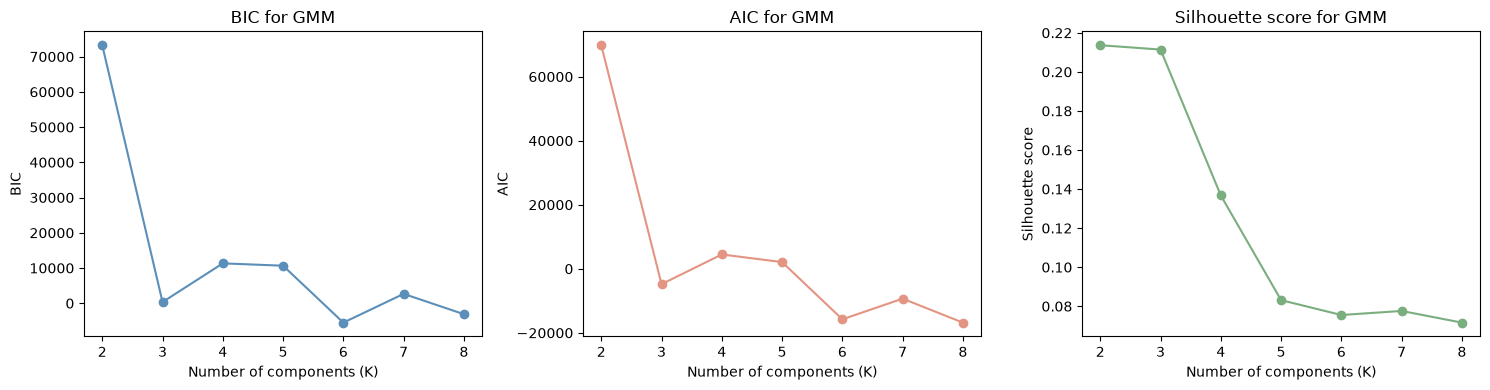

K with highest silhouette score: 2


In [167]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

K_range = range(2, 9)

bic_scores = []
aic_scores = []
sil_scores = []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        random_state=RANDOM_STATE
    )
    
    labels = gmm.fit_predict(X_scaled)

    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    sil_scores.append(silhouette_score(X_scaled, labels))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(K_range), bic_scores, "o-", color="#5B8FB9")
axes[0].set_xlabel("Number of components (K)")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC for GMM")

axes[1].plot(list(K_range), aic_scores, "o-", color="#E39482")
axes[1].set_xlabel("Number of components (K)")
axes[1].set_ylabel("AIC")
axes[1].set_title("AIC for GMM")

axes[2].plot(list(K_range), sil_scores, "o-", color="#7BAE7F")
axes[2].set_xlabel("Number of components (K)")
axes[2].set_ylabel("Silhouette score")
axes[2].set_title("Silhouette score for GMM")

plt.tight_layout()
plt.show()


best_k_gmm = list(K_range)[int(np.argmax(sil_scores))]
print("K with highest silhouette score:", best_k_gmm)

# Fit final GMM model
gmm_final = GaussianMixture(
    n_components=best_k_gmm,
    random_state=RANDOM_STATE
)

gmm_labels = gmm_final.fit_predict(X_scaled)

In [ ]:
df_hc = data.copy()

hc_5 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hc_labels_5 = hc_5.fit_predict(X_scaled)

df_hc["Cluster"] = hc_labels_5

cluster_profile_5 = df_hc.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Income=("Income", "mean"),
    Avg_Age=("Age", "mean"),
    Avg_Recency=("Recency", "mean"),
    Avg_Web_Purchases=("NumWebPurchases", "mean"),
    Avg_Catalog_Purchases=("NumCatalogPurchases", "mean"),
    Avg_Store_Purchases=("NumStorePurchases", "mean"),
    Avg_Web_Visits=("NumWebVisitsMonth", "mean"),
    Avg_Deals=("NumDealsPurchases", "mean"),
    Avg_Promotions=("Promotions", "mean"),
    Avg_Complaints=("Complain", "mean"),
    Avg_Tenure=("Days_enrolled", "mean")
)

cluster_profile_5

# 0: Young web window shoppers
# 1: Big spenders
# 2: Catalog store buyers, few deals, more promos
# 3: Complainers
# 4: Dormant

,Customers,Avg_Income,Avg_Age,Avg_Recency,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Avg_Web_Visits,Avg_Deals,Avg_Promotions,Avg_Complaints,Avg_Tenure
Cluster,,,,,,,,,,,,
0,1005,10.386840,45.884577,49.973134,2.103483,0.569154,3.301493,6.337313,1.960199,0.161194,0.0,1228.665672
1,689,10.941932,50.867925,46.358491,6.480406,3.261248,7.766328,5.796807,3.666183,0.368650,0.0,1346.939042
2,502,11.236046,48.894422,50.503984,4.830677,6.089641,8.119522,2.595618,1.203187,1.139442,0.0,1246.830677
3,21,10.626500,51.904762,53.047619,3.619048,2.047619,5.238095,5.809524,2.333333,0.285714,1.0,1339.380952
4,23,NaN,50.347826,59.739130,3.043478,1.913043,5.000000,5.260870,2.565217,0.304348,0.0,1270.347826


In [168]:
import itertools

corr = data.corr(numeric_only=True)['Spent'].sort_values(ascending=False)
print(corr)

results = []

numeric_cols = data.select_dtypes(include='number').columns.drop('Spent')

for col1, col2 in itertools.combinations(numeric_cols, 2):
    
    # Multiplication interaction
    interaction_mult = data[col1] * data[col2]
    corr_mult = interaction_mult.corr(data['Spent'])
    results.append([f'{col1} * {col2}', corr_mult])
    
    # Division interaction
    interaction_div = data[col1] / data[col2].replace(0, np.nan)
    corr_div = interaction_div.corr(data['Spent'])
    results.append([f'{col1} / {col2}', corr_div])

interaction_corr = pd.DataFrame(
    results,
    columns=['Interaction', 'Correlation']
).sort_values(
    'Correlation',
    ascending=False
)

print(interaction_corr)

Spent                  1.000000
MntWines               0.891839
MntMeatProducts        0.842965
NumCatalogPurchases    0.778577
Income                 0.696522
NumStorePurchases      0.674669
MntFishProducts        0.642818
MntFruits              0.614229
MntSweetProducts       0.603016
MntGoldProds           0.524262
NumWebPurchases        0.519837
Promotions             0.456206
Days_enrolled          0.158814
Age                    0.111306
Education              0.064540
Recency                0.020433
Marital_Status        -0.016054
Complain              -0.037058
NumDealsPurchases     -0.065112
Teenhome              -0.138384
NumWebVisitsMonth     -0.500218
Kidhome               -0.556669
Name: Spent, dtype: float64
                              Interaction  Correlation
231                   MntWines / Complain     0.938879
281            MntMeatProducts / Complain     0.937653
383        NumCatalogPurchases / Complain     0.900579
84                      Income * MntWines     0.

In [169]:
data['IncomePerComplaint'] = data['Income']/(data['Complain']+1)
data.drop(columns=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"], inplace=True)

In [170]:
y = data["Spent"]
data.drop(columns=["Spent"], inplace=True)
X = data

In [171]:
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

def model_performance_regression(model, predictors, target):
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(predictors, target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)

    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )
    return df_perf

import warnings

warnings.filterwarnings("ignore")

In [172]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   int64  
 1   Marital_Status       2240 non-null   int64  
 2   Income               2216 non-null   float64
 3   Kidhome              2240 non-null   int64  
 4   Teenhome             2240 non-null   int64  
 5   Recency              2240 non-null   int64  
 6   NumDealsPurchases    2240 non-null   int64  
 7   NumWebPurchases      2240 non-null   int64  
 8   NumCatalogPurchases  2240 non-null   int64  
 9   NumStorePurchases    2240 non-null   int64  
 10  NumWebVisitsMonth    2240 non-null   int64  
 11  Complain             2240 non-null   int64  
 12  Age                  2240 non-null   int64  
 13  Days_enrolled        2240 non-null   int64  
 14  Promotions           2240 non-null   int64  
 15  IncomePerComplaint   2216 non-null   f

In [173]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median", add_indicator=True)),
    ('scaler', StandardScaler())
])

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train_scaled = numeric_pipeline.fit_transform(x_train)   # fit + transform
X_test_scaled  = numeric_pipeline.transform(x_test)


In [174]:
regressors = {
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

results = []

for name, reg in regressors.items():
    reg.fit(X_train_scaled, y_train)
    preds = reg.predict(X_test_scaled)
    
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'MSE': mean_squared_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R²': r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R²
0,XGBoost Regressor,107.912109,47338.613281,217.574386,0.870768
1,Random Forest Regressor,114.805223,49014.861940,221.393003,0.866192
2,Ridge Regression,192.991130,81372.042461,285.257853,0.777858
3,Lasso Regression,193.181978,81604.698348,285.665361,0.777223


In [175]:
# K_range = range(2, 9)
# inertias = []
# sil_scores = []

# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
#     labels = km.fit_predict(X_scaled)
#     inertias.append(km.inertia_)
#     sil_scores.append(silhouette_score(X_scaled, labels))

# fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# axes[0].plot(list(K_range), inertias, "o-", color="#5B8FB9")
# axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")

# axes[1].plot(list(K_range), sil_scores, "o-", color="#E39482")
# axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette score by K")
# plt.tight_layout()
# plt.show()

# best_k = list(K_range)[int(np.argmax(sil_scores))]
# print("K with the highest silhouette score:", best_k)
